In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.shape

(7043, 21)

In [11]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df["customerID"].duplicated().sum()

np.int64(0)

In [15]:
df["TotalCharges"].astype(str).str.isspace()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [18]:
df.apply(lambda col:col.astype(str).str.strip() =="").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### Replacing blanks with 0 as tenure is 0 

In [19]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Converted 0 and 1 values of senior citizen to yes/no for easy understanding

In [4]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "yes", 0: "no"})

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


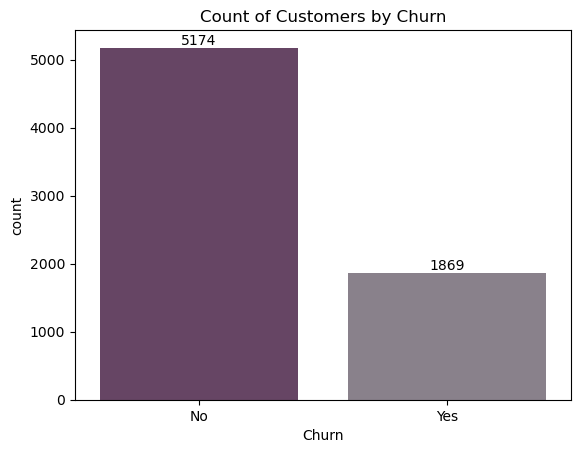

In [142]:
colors = ['#6B3F69','#8A7F8D']
ax = sns.countplot(x = "Churn",data=df,hue="Churn",palette = colors)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Customers by Churn")
plt.show()

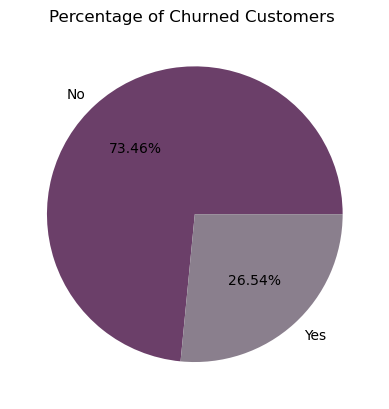

In [132]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb["Churn"],labels = gb.index,autopct = '%1.2f%%',colors = ['#6B3F69','#8A7F8D'])
plt.title("Percentage of Churned Customers ")
plt.show()

### Customer churn analysis reveals that approximately 26.5% of customers have discontinued the service, while 73.5% remain retained. This indicates that roughly one in four customers is lost, signaling a moderate but business-critical churn rate that warrants strategic attention.

### Although the majority of customers are retained, a churn rate above 20% can significantly impact recurring revenue, customer lifetime value, and long-term profitability.

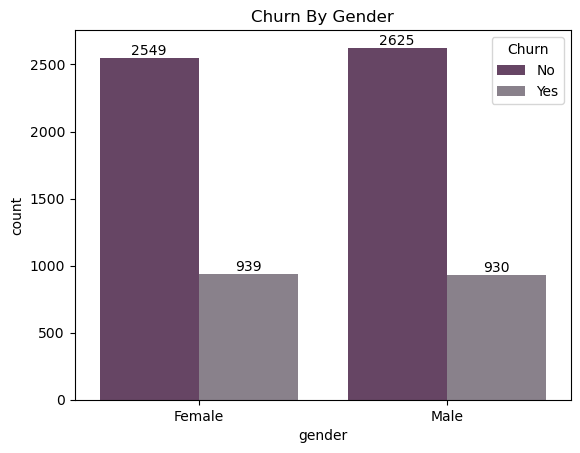

In [130]:
ax = sns.countplot(x="gender",data = df,hue='Churn',palette =  ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Churn By Gender")
plt.show()

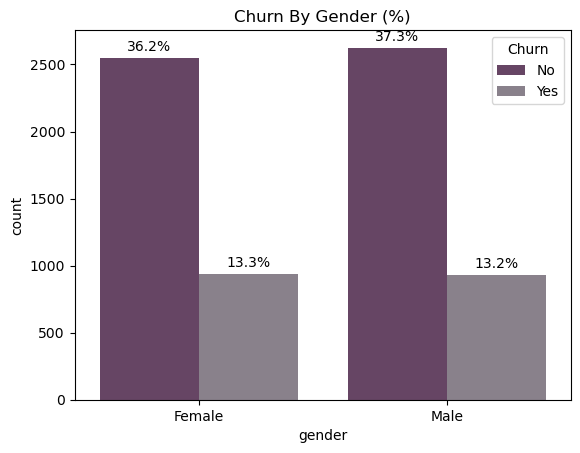

In [129]:
total = len(df)

ax = sns.countplot(x="gender", data=df, hue="Churn",palette = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    labels = [f'{(bar.get_height()/total)*100:.1f}%' for bar in container]
    
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Churn By Gender (%)")
plt.show()

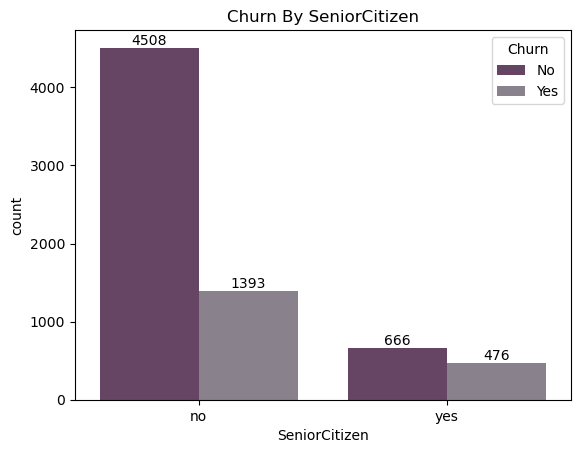

In [128]:
ax = sns.countplot(x="SeniorCitizen",data = df,hue='Churn',palette =  ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Churn By SeniorCitizen")
plt.show()

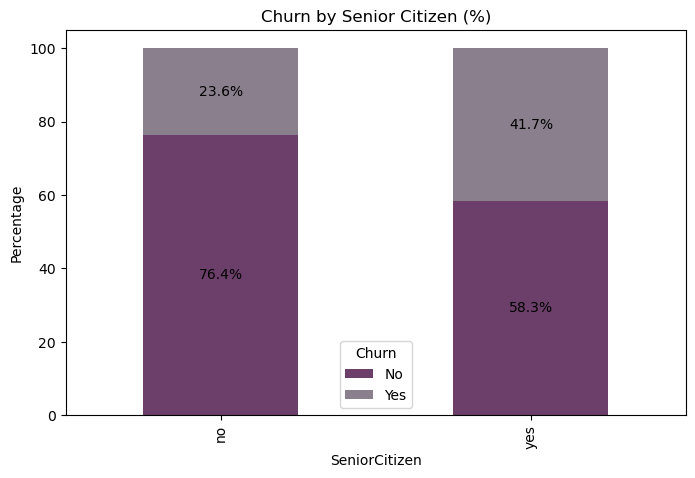

In [127]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_pct.plot(kind='bar', stacked=True, figsize=(8,5),color = ['#6B3F69','#8A7F8D'])

plt.title("Churn by Senior Citizen (%)")
plt.ylabel("Percentage")
plt.legend(title="Churn")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

### Senior citizens demonstrate a significantly higher churn rate compared to non-senior customers. Approximately 41.7% of senior citizens have churned, nearly double the churn rate of non-senior customers at 23.6%. Meanwhile, over 76% of non-senior customers remain retained, indicating stronger customer stability within this segment.

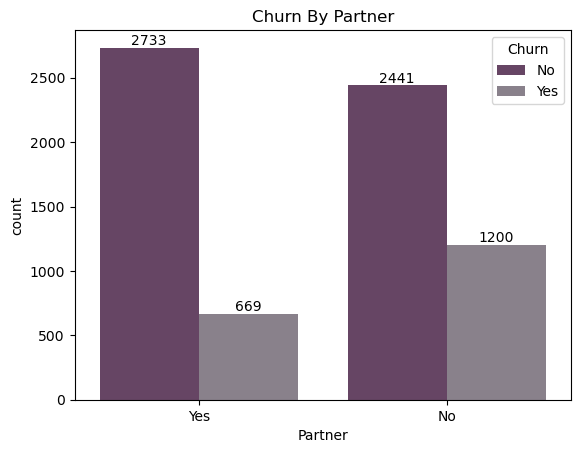

In [126]:
colors = ['#6B3F69','#8A7F8D']
ax = sns.countplot(x = 'Partner',data=df,hue="Churn",palette = colors)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn By Partner")
plt.show()

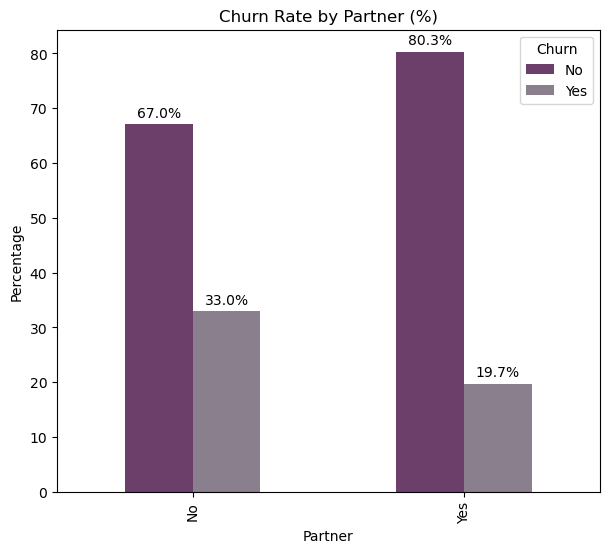

In [198]:
ct = pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=False, figsize=(7,6),color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Churn Rate by Partner (%)")
plt.ylabel("Percentage")
plt.show()

### Partner status shows a strong relationship with customer churn. Customers without a partner exhibit a significantly higher churn rate (33%) compared to customers with a partner (19.7%)

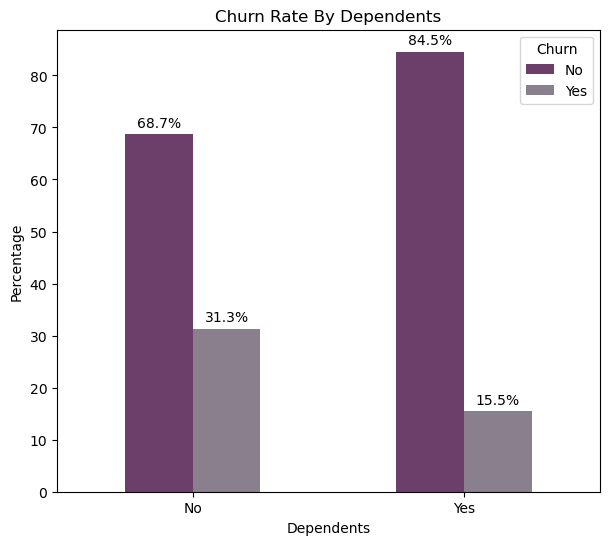

In [152]:
ct = pd.crosstab(df["Dependents"],df["Churn"],normalize='index') * 100

ax = ct.plot(kind='bar',stacked=False,figsize=(7,6),color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',padding=3)
    
plt.title("Churn Rate By Dependents")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Customers without dependents exhibit a significantly higher churn rate (31.3%) compared to customers with dependents (15.5%). Conversely, customers with dependents show substantially stronger retention, with approximately 84.5% remaining with the company.

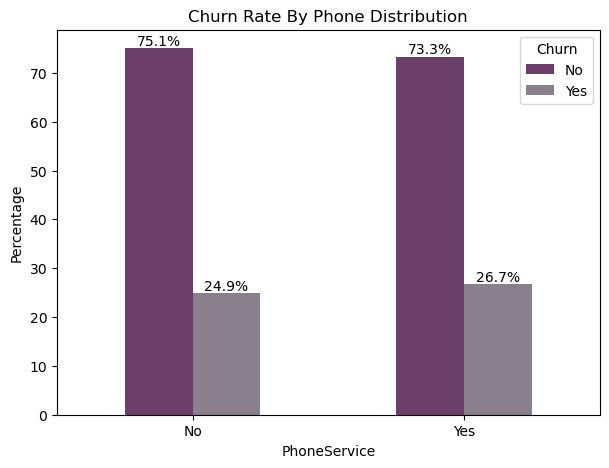

In [169]:
ct = pd.crosstab(df["PhoneService"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (7,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Phone Distribution")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### The analysis indicates that churn behavior is relatively consistent across customers regardless of phone service adoption. Customers without phone service exhibit a churn rate of approximately 24.9%, while customers with phone service churn at a slightly higher rate of 26.7%.

### The marginal difference (~1.8%) suggests that phone service is not a primary driver of customer attrition and likely has minimal influence on retention outcomes.

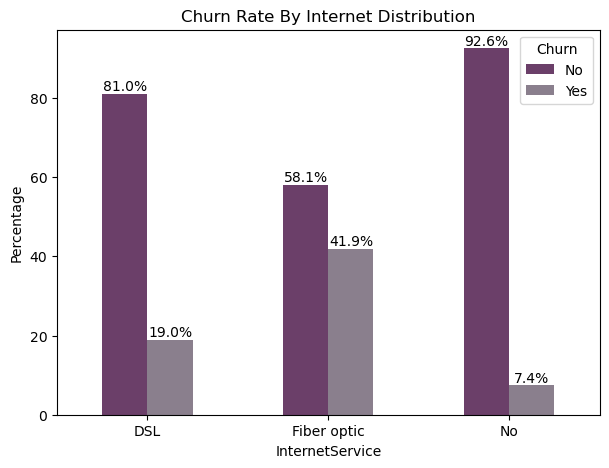

In [168]:
ct = pd.crosstab(df["InternetService"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (7,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Internet Distribution")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Internet service type demonstrates a strong relationship with customer churn. Customers subscribed to fiber optic services exhibit the highest churn rate at approximately 41.9%, significantly exceeding DSL users (19.0%) and customers without internet service (7.4%).

### Despite being a premium offering, fiber optic customers appear substantially more likely to discontinue the service, indicating a potential gap between customer expectations and perceived value

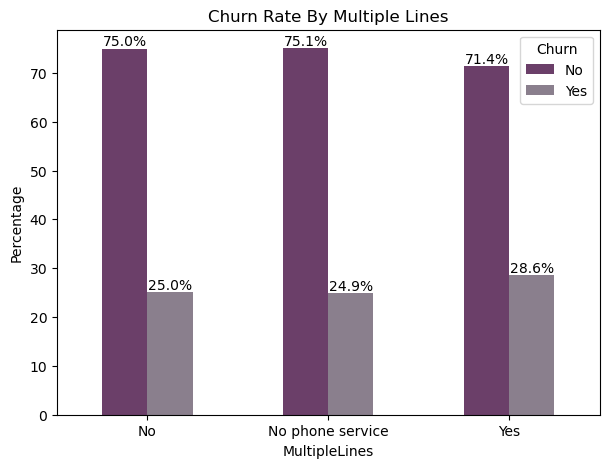

In [167]:
ct = pd.crosstab(df["MultipleLines"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (7,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Multiple Lines")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### The analysis indicates that the presence of multiple phone lines has minimal impact on customer churn behavior. Customers without multiple lines churn at a rate of approximately 25.0%, while those with multiple lines exhibit a slightly higher churn rate of 28.6%. Customers without phone service show nearly identical churn patterns (24.9%).

### The relatively small variance across segments suggests that multiple line subscriptions are not a primary determinant of customer attrition.

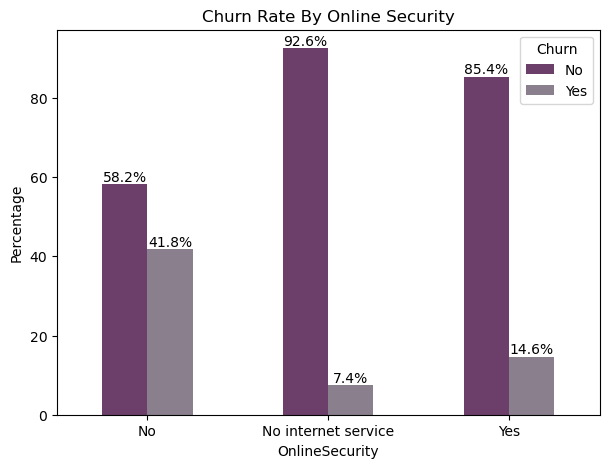

In [166]:
ct = pd.crosstab(df["OnlineSecurity"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (7,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Online Security")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Online security adoption demonstrates a strong inverse relationship with customer churn. Customers without online security exhibit a significantly elevated churn rate of approximately 41.8%, whereas customers with online security churn at a substantially lower rate of 14.6%. Customers without internet service show minimal churn (7.4%), likely reflecting lower service dependency and simpler product expectations.

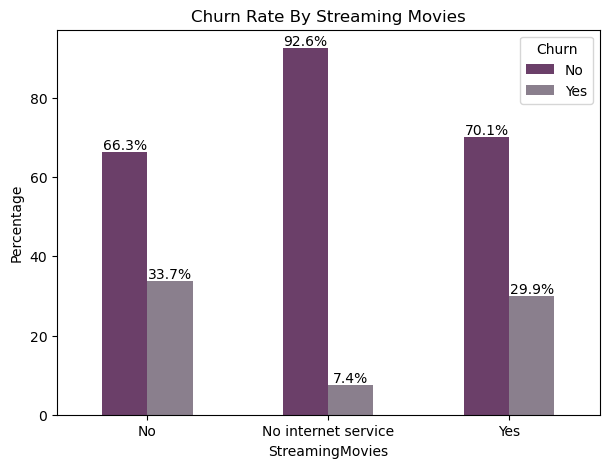

In [165]:
ct = pd.crosstab(df["StreamingMovies"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (7,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Streaming Movies")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Streaming movie subscriptions show a moderate relationship with customer churn. Customers without streaming services churn at a higher rate (33.7%) compared to those who subscribe (29.9%). Customers without internet service exhibit minimal churn (7.4%), likely reflecting lower product complexity and fewer service expectations.

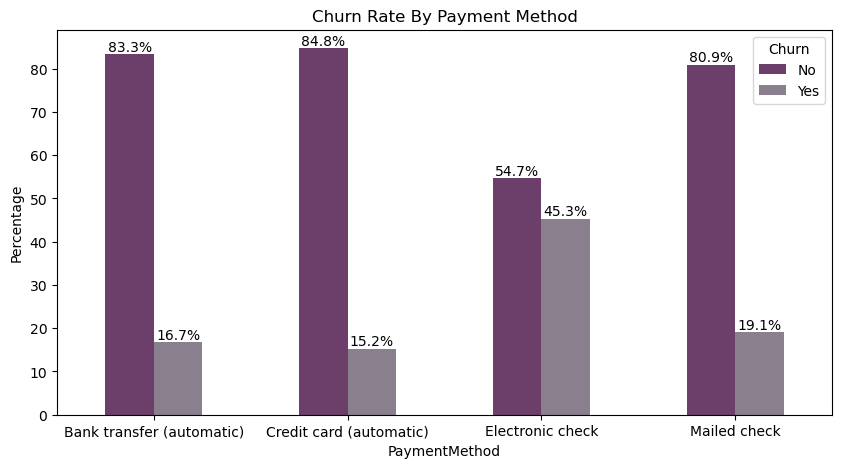

In [195]:
ct = pd.crosstab(df["PaymentMethod"],df["Churn"],normalize='index')*100

ax = ct.plot(kind='bar',stacked = False, figsize = (10,5), color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Churn Rate By Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Payment method demonstrates a significant relationship with customer churn. Customers using electronic checks exhibit the highest churn rate at approximately 45.3%, dramatically exceeding all other payment types. In contrast, customers enrolled in automatic payment methods — such as credit cards (15.2%) and bank transfers (16.7%) — show substantially stronger retention. Mailed check users display moderate churn levels at 19.1%.

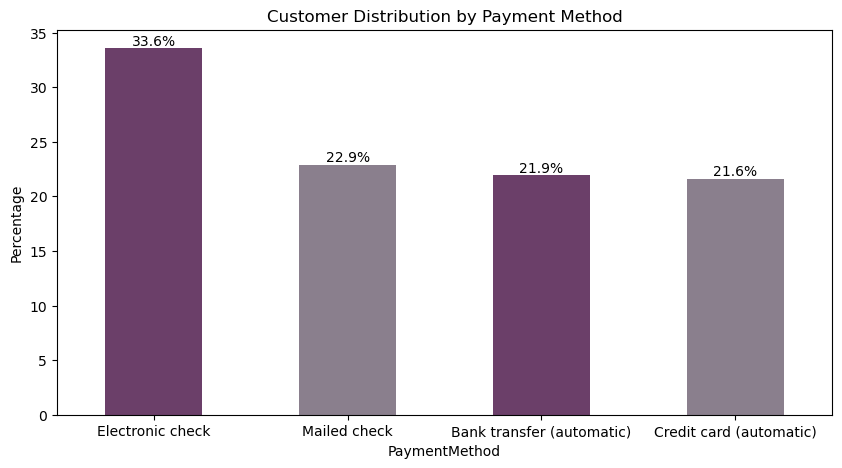

In [206]:
dist = df["PaymentMethod"].value_counts(normalize=True) *100
plt.figure(figsize=(10,5))

ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Customer distribution analysis reveals that electronic check is the most commonly used payment method, accounting for approximately 33.6% of the customer base. Mailed checks (22.9%), bank transfers (21.9%), and credit card payments (21.6%) follow with relatively similar adoption levels.

### The high concentration of customers using electronic checks becomes particularly significant when viewed alongside its elevated churn rate, indicating a potential structural risk within a large customer segment.

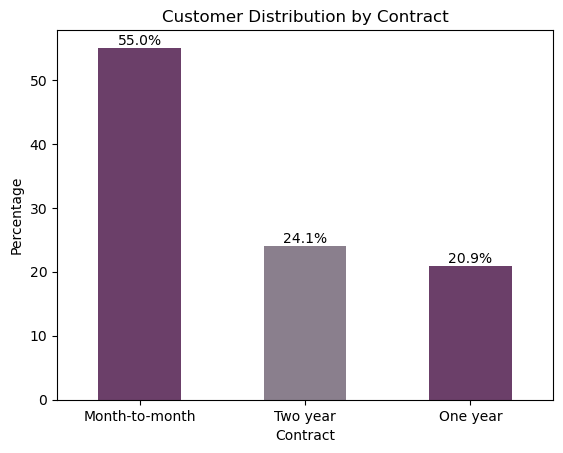

In [203]:
dist = df["Contract"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Month-to-month contracts dominate the customer base, representing approximately 55% of all customers, while one-year (20.9%) and two-year (24.1%) contracts account for significantly smaller shares.

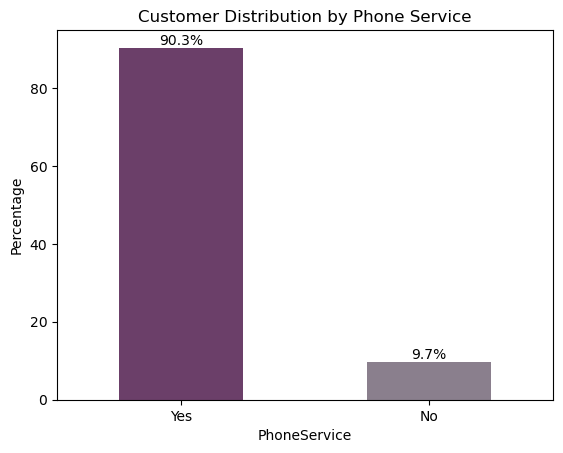

In [148]:
dist = df["PhoneService"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Phone Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Phone service adoption is nearly universal, with about 90.3% of customers subscribed, while only 9.7% do not use the service. This indicates that phone service is a core offering and a standard part of the customer package rather than a differentiating feature.

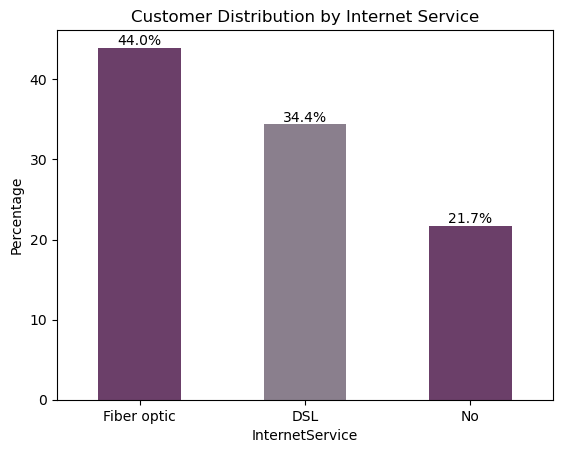

In [157]:
dist = df["InternetService"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Fiber optic is the most widely adopted internet service (44%), followed by DSL (34.4%), while 21.7% of customers do not subscribe to internet services. The strong preference for fiber suggests a growing demand for high-speed connectivity and premium service experiences.

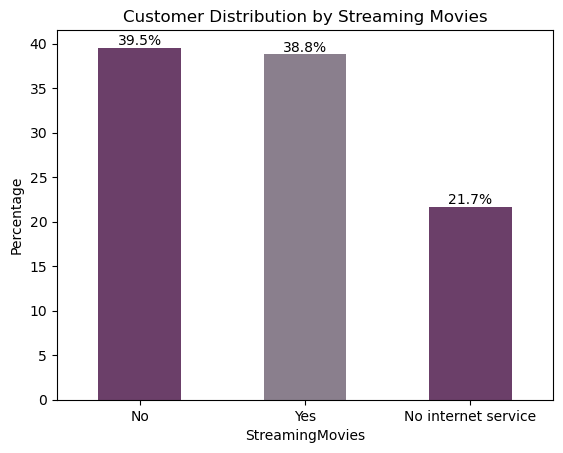

In [171]:
dist = df["StreamingMovies"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Streaming Movies")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Streaming movie adoption is evenly split, with 38.8% of customers subscribed and 39.5% not using the service, while 21.7% lack internet access. This balanced distribution suggests streaming is a value-added feature rather than a core service.

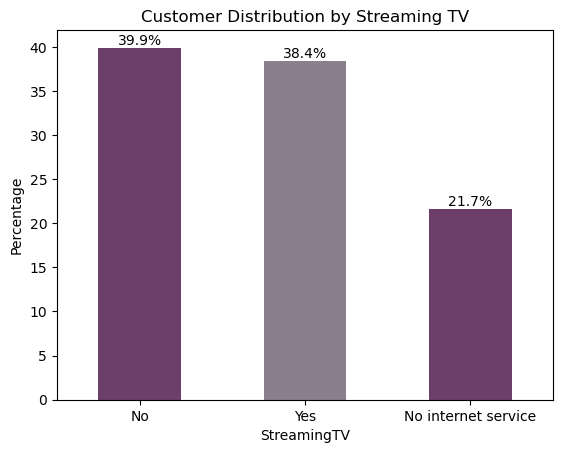

In [172]:
dist = df["StreamingTV"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Streaming TV")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Streaming TV adoption is nearly balanced, with 38.4% of customers subscribed and 39.9% not using the service, while 21.7% do not have internet access. This indicates that streaming TV functions primarily as a supplementary service rather than a core offering.

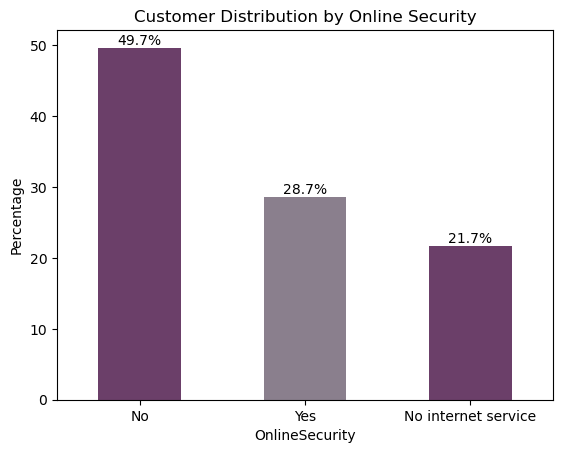

In [173]:
dist = df["OnlineSecurity"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Online Security")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Nearly half of the customers (49.7%) do not have online security, while only 28.7% have adopted the service, and 21.7% lack internet access. This low adoption highlights a significant gap in a feature that enhances customer value and protection.

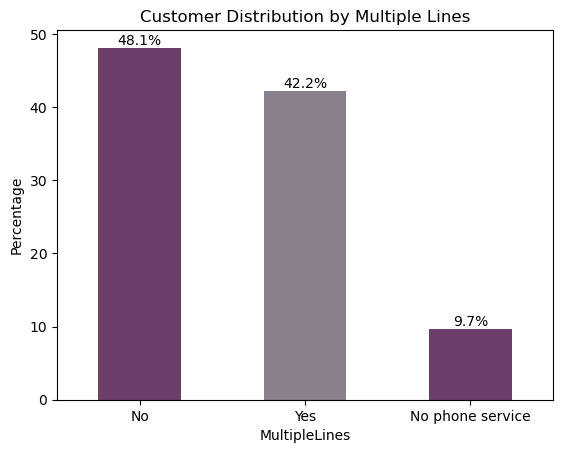

In [174]:
dist = df["MultipleLines"].value_counts(normalize=True) *100
ax = dist.plot(kind='bar',color = ['#6B3F69','#8A7F8D'])

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%')

plt.title("Customer Distribution by Multiple Lines")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Multiple line adoption is relatively balanced, with 42.2% of customers subscribed and 48.1% not using the service, while 9.7% do not have phone service. This suggests multiple lines are an optional enhancement rather than a core customer requirement.